## Logistic Regression Model

In [75]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/liameikill/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [76]:
df = pd.read_csv("../../reviews.csv", encoding="utf-8")
df.head(10)

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


## Text Preprocessing

- **Lowercasing:** Reduces vocabulary size 
- **Remove URLs / emails / special characters:** These carry no sentiment and just add noise
- **Remove extra whitespace:** Normalises the input
- **Stop words:** We intentionally keep some stop words like "not", "no", "very" because they carry sentiment.
- **Remove empty rows**

In [78]:
df = pd.read_csv("../../reviews.csv")
print(f"Shape: {df.shape}")


stop_words = set(stopwords.words("english"))

sentiment_keepers = {
    'not','no','nor','never','very','too','most','more','less','least',
    'few','but','however','although','only','just'
}

stop_words = stop_words - sentiment_keepers

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text) #URL 
    text = re.sub(r"\S+@\S+", "", text) #Email
    text = re.sub(r"[^a-z\s]", "", text) #Non-letters
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["review_text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("\nRemaining rows:", df.shape[0])

Shape: (6210, 5)

Remaining rows: 6168


## Converting to sentiment labels

To simplify the prediction, the numerical ratings are converted into sentiment labels. Ratings of 1 and 2 are classified as negative, 3 as neutral, and 4 and 5 as positive. This transforms the problem into a classification task with three categories instead of five. Grouping the ratings in this way also helps reduce the impact of class imbalance. The resulting sentiment labels are used as the target variable for the model.

In [79]:
def to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

y = df["rating"].apply(to_sentiment)
X = df["clean_text"] 

## Train-Test Split
 
We split the data into 85% training and 15% test sets, while keeping the same distribution of ratings in both. This is done using stratified sampling, which helps handle the class imbalance. It ensures that all rating classes are fairly represented in both sets. The training set is used to train the model, while the test set is used to evaluate its performance. This gives a more reliable measure of how well the model works on new data.

In [83]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train_raw)} samples")
print(f"Test set:     {len(X_test_raw)} samples")

Training set: 5242 samples
Test set:     926 samples


## TF-IDF Feature Extraction

Logistic regression require numerical input, so the text data must be converted into numbers. To do this, we use TF-IDF, which represents each review as a vector based on the importance of its words. TF-IDF gives higher weight to words that are important in a specific review but less common across all reviews. This helps the model focus on meaningful words that distinguish between different ratings. The resulting numerical vectors are then used as input for training the model.

- **max_features=5000**: Limits the vocabulary to the 5000 most informative words to reduce dimensionality and improve computational efficiency.
- **ngram_range=(1,2)**: Includes both single words (unigrams) and pairs of words (bigrams), allowing the model to capture short phrases such as “not working” or “very good”.
- **min_df=5**: Ignores words that appear in fewer than five reviews, helping to remove noise and extremely rare terms.

In [84]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),  
    min_df=5
)

X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

## Train the model

LRM is trained on the training data. The model learns the relationship between the TF-IDF features and the corresponding sentiment labels.

**max_iter=1000:** ensures that the model has enough iterations to converge during training. After this step, the model is ready to make predictions on new, unseen data.

In [85]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Make prediticion

The logistic regression model is used to make predictions on the test data. The model assigns a sentiment label to each review based on the learned patterns from the training set. These predictions are stored in **y_pred** and will be used to evaluate the model’s performance.

In [86]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Text": X_test_raw,   
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Text,Actual,Predicted
3748,get phonepay display,positive,positive
1871,near near near near near near near near near n...,positive,positive
2788,nice aap easy use good communicate others easi...,positive,positive
1890,pls dont know say not workout,negative,positive
2837,good app,positive,positive
325,showing use official account not working,positive,negative
4091,surely best app could ever edit years later st...,positive,positive
626,show very well app,positive,positive
5618,hello whatsapp please remove meta symbol chat ...,neutral,negative
1534,very graceful app,positive,positive


## Evaluation

We use accuracy to measure the overall percentage of correct predictions. In addition, we use a classification report to check how well the model performs for each class using precision, recall, and F1-score. This is important because accuracy alone can hide poor performance on minority classes.

Here we also use a confusion matrix to visually compare the predicted labels with the actual labels. It helps us see exactly where the model is making mistakes, for example confusing neutral reviews with positive or negative ones.

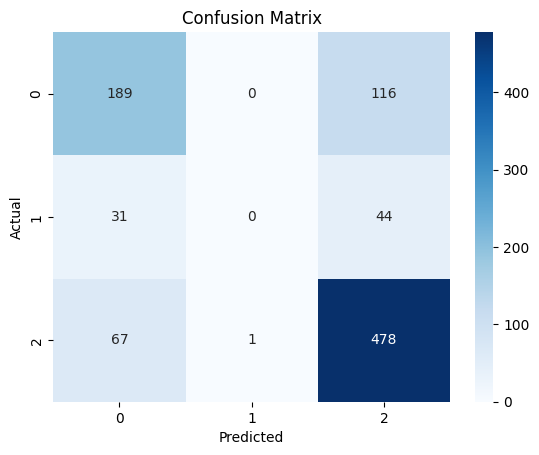

In [88]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()